First 5 Rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       248
           1       0.97      1.00      0.99       225

    accuracy                           0.99       473
   macro avg       0.99      0.99      0.99       473
weighted avg       0.99      0.99      0.99       473

ROC-AUC: 0.998405017921147

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       248
           1       1.00      1.00      1.00       225

    accuracy                           1.00       473
   macro avg       1.00      1.00      1.00       473
weighted avg       1.00      1.00      1.00       473

ROC-AUC: 1.0


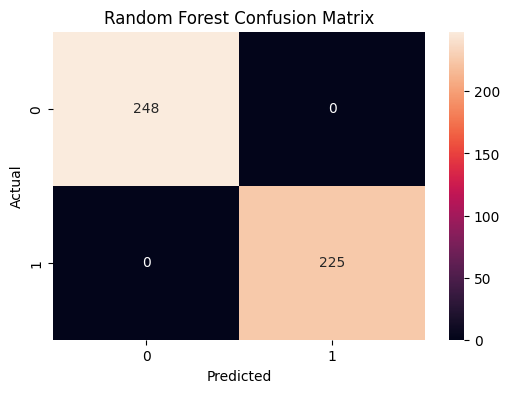

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# -----------------------------
# STEP 1: Load Dataset
# -----------------------------
df = pd.read_excel("Dataset for Data Analytics.xlsx")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

# -----------------------------
# STEP 2: Handle Missing Values
# -----------------------------
df.replace(["NA", "Unknown", ""], np.nan, inplace=True)

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
df = df.drop_duplicates()

# -----------------------------
# STEP 3: Create Fraud Column
# -----------------------------
df['Fraud'] = (
    (df['TotalPrice'] > 2500) &
    (df['Quantity'] >= 4) &
    (df['PaymentMethod'] == 'Online')
).astype(int)

print("\nFraud Distribution:")
print(df['Fraud'].value_counts())

# -----------------------------
# STEP 4: Drop Unnecessary Columns
# -----------------------------
drop_cols = ['OrderID', 'CustomerID', 'ShippingAddress', 'TrackingNumber']
df.drop(columns=drop_cols, inplace=True)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.drop(columns=['Date'], inplace=True)

# -----------------------------
# STEP 5: Label Encoding
# -----------------------------
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

# -----------------------------
# STEP 6: Split Features and Target
# -----------------------------
X = df.drop('Fraud', axis=1)
y = df['Fraud']

print("\nBefore SMOTE:")
print(y.value_counts())

# -----------------------------
# STEP 7: Apply SMOTE
# -----------------------------
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(pd.Series(y_smote).value_counts())

# -----------------------------
# STEP 8: Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42
)

# -----------------------------
# STEP 9: Logistic Regression
# -----------------------------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print("\n===== Logistic Regression =====")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

# -----------------------------
# STEP 10: Random Forest
# -----------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("\n===== Random Forest =====")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

# -----------------------------
# STEP 11: Confusion Matrix
# -----------------------------
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()